# 03 - Baseline Training

Train the price-only transformer (6 features, 30-day window) end-to-end on
the train split, using the val split for early stopping. Save the best
checkpoint to `results/models/baseline.pt`. All plots are local to this
notebook; no plotting code lives in `/src`.


In [1]:
import sys, time, platform
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, torch
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 110

from src import data_loader as dl, train as tr
from src.baseline_model import BaselineTransformer
from src.data_loader import MODELS_DIR, PLOTS_DIR, SEED
from src.train import TrainConfig

MODELS_DIR.mkdir(parents=True, exist_ok=True); PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print('Python :', platform.python_version(), '| torch:', torch.__version__,
      '| CUDA:', torch.cuda.is_available())


Python : 3.14.3 | torch: 2.11.0+cpu | CUDA: False


## 1. Data

In [2]:
ds = dl.assemble_dataset(use_sentiment=False, window=30)
print('train:', ds['X_train'].shape, ds['y_train'].shape)
print('val  :', ds['X_val'].shape,   ds['y_val'].shape)
print('test :', ds['X_test'].shape,  ds['y_test'].shape)
print('features:', ds['feature_names'])


train: (4343, 30, 6) (4343, 3)
val  : (943, 30, 6) (943, 3)
test : (939, 30, 6) (939, 3)
features: ['Open', 'High', 'Low', 'Close', 'Volume', 'MACD']


## 2. Model + training config

In [3]:
tr.set_seed(SEED)
model = BaselineTransformer(n_features=6, seq_len=30,
                            d_model=128, n_heads=2, ffn_dim=128, dropout=0.1)
n_params = sum(p.numel() for p in model.parameters())
print(f'Baseline params: {n_params:,}')
print(model)


Baseline params: 112,771
BaselineTransformer(
  (proj): Linear(in_features=6, out_features=128, bias=True)
  (pos_emb): Embedding(30, 128)
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (ffn): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [4]:
cfg = TrainConfig(epochs=60, batch_size=64, lr=1e-3, weight_decay=1e-5,
                  grad_clip=1.0, early_stopping_patience=8, seed=SEED)
print(cfg)


TrainConfig(epochs=60, batch_size=64, lr=0.001, weight_decay=1e-05, grad_clip=1.0, early_stopping_patience=8, seed=42)


## 3. Train

In [5]:
save_path = MODELS_DIR / 'baseline.pt'
log_rows = []

def on_epoch(epoch, tloss, vloss, dt, improved):
    flag = '<-- best' if improved else ''
    print(f'epoch {epoch:>3} | train MSE {tloss:.6f} | val MSE {vloss:.6f}'
          f' | {dt:5.1f}s {flag}')
    log_rows.append({'epoch': epoch, 'train_loss': tloss, 'val_loss': vloss, 'seconds': dt})

t0 = time.time()
history = tr.train_model(model, ds['X_train'], ds['y_train'],
                         ds['X_val'], ds['y_val'],
                         cfg, save_path, on_epoch_end=on_epoch)
print(f'Done in {history.total_seconds:.1f}s; best val MSE {history.best_val_loss:.6f}'
      f' at epoch {history.best_epoch}/{len(history.train_loss)}.')


epoch   1 | train MSE 0.003267 | val MSE 0.001242 |   0.9s <-- best


epoch   2 | train MSE 0.000876 | val MSE 0.001641 |   0.9s 


epoch   3 | train MSE 0.000853 | val MSE 0.001837 |   0.9s 


epoch   4 | train MSE 0.000864 | val MSE 0.001637 |   0.9s 


epoch   5 | train MSE 0.000868 | val MSE 0.001165 |   0.9s <-- best


...

epoch  16 | train MSE 0.000845 | val MSE 0.000822 |   1.0s 


epoch  17 | train MSE 0.000810 | val MSE 0.001239 |   1.0s 


epoch  18 | train MSE 0.000811 | val MSE 0.001195 |   1.0s 


epoch  19 | train MSE 0.000828 | val MSE 0.000813 |   1.0s 


epoch  20 | train MSE 0.000845 | val MSE 0.000820 |   0.9s 
Done in 19.1s; best val MSE 0.000793 at epoch 12/20.


## 4. Loss curves

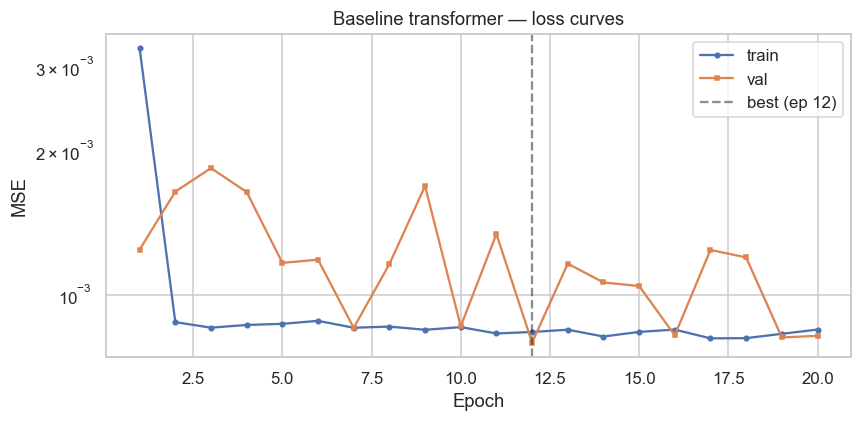

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs = np.arange(1, len(history.train_loss) + 1)
ax.plot(epochs, history.train_loss, label='train', marker='o', ms=3)
ax.plot(epochs, history.val_loss, label='val', marker='s', ms=3)
ax.axvline(history.best_epoch, color='k', ls='--', alpha=0.5, label=f'best (ep {history.best_epoch})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.set_title('Baseline transformer - loss curves')
ax.set_yscale('log'); ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_baseline_loss_curves.png', dpi=150)
plt.show()


## 5. Save training log + summary

In [7]:
log = pd.DataFrame(log_rows)
log.to_csv(dl.PROJECT_ROOT / 'results' / 'baseline_train_log.csv', index=False)
print('saved baseline_train_log.csv')
log.tail()


saved baseline_train_log.csv


,epoch,train_loss,val_loss,seconds
15,16,0.000845,0.000822,1.014274
16,17,0.000810,0.001239,1.039447
17,18,0.000811,0.001195,1.045194
18,19,0.000828,0.000813,0.967468
19,20,0.000845,0.000820,0.948491


**Summary:** baseline transformer trained on 6 price features over a
30-day window. Best checkpoint saved to `results/models/baseline.pt`.
Loss curve in `results/plots/03_baseline_loss_curves.png`.
